In [1]:

import os
import glob
import sys
sys.path.append('/hkfs/work/workspace/scratch/cc7738-automorphism/orbit-gnn/')  # Replace with the actual path

# Specify the folder path
folder_path = '/hkfs/work/workspace/scratch/cc7738-automorphism/orbit-gnn'

# Use glob to get all the PDF files in the folder
pdf_files = glob.glob(os.path.join(folder_path, '*.pdf'))

# Loop through all the files and delete them
for pdf_file in pdf_files:
    try:
        os.remove(pdf_file)
        print(f"Deleted: {pdf_file}")
    except Exception as e:
        print(f"Error deleting {pdf_file}: {e}")
from collections import Counter

In [2]:
import networkx as nx
import pynauty

def get_graph_orbits(graph: nx.Graph) -> list:
    # Map nodes to consecutive indices
    node_mapping = {node: idx for idx, node in enumerate(graph.nodes())}
    
    # Create adjacency dictionary with remapped indices
    adj_dict = {
        node_mapping[node]: [node_mapping[neighbor] for neighbor in graph.neighbors(node)]
        for node in graph.nodes()
    }
    
    # Construct pynauty graph
    n = len(graph.nodes())
    G_pynauty = pynauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict, directed=False)
    
    # Compute orbits
    _, _, _, orbits, num_orbit = pynauty.autgrp(G_pynauty)
    
    return orbits, num_orbit

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def plot_degree_distribution(G):
    # Get degree of each node
    degrees = [d for _, d in G.degree()]
    # Count how many nodes have each degree
    degree_counts = Counter(degrees)
    xs = sorted(degree_counts.keys())
    ys = [degree_counts[x] for x in xs]

    # Make the bar‐chart
    plt.figure()
    plt.bar(
        xs,
        ys,
        width=0.8,               # 柱宽，可根据需要调整
        edgecolor='black',       # 边框颜色
        linewidth=0.5,           # 边框线宽
        facecolor='none',        # 填充设为空心
        align='center'           # 居中对齐
    )
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.title("Degree Distribution")
    plt.xticks(xs)
    plt.tight_layout()
    plt.show()

# Example usage:
# import networkx as nx
# G = nx.your_graph_loader_or_constructor(...)
# plot_degree_distribution(G)




Number of orbits: 3, Tree depth: 2


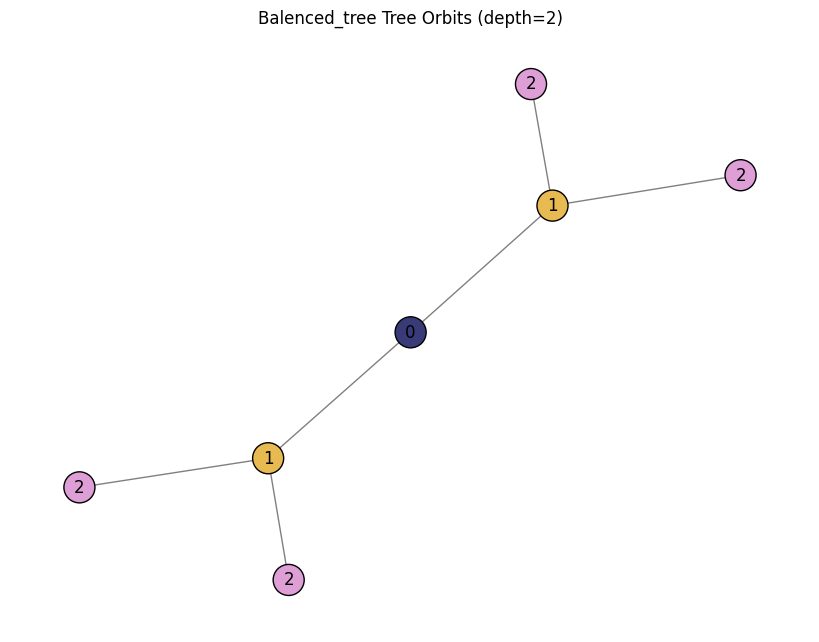

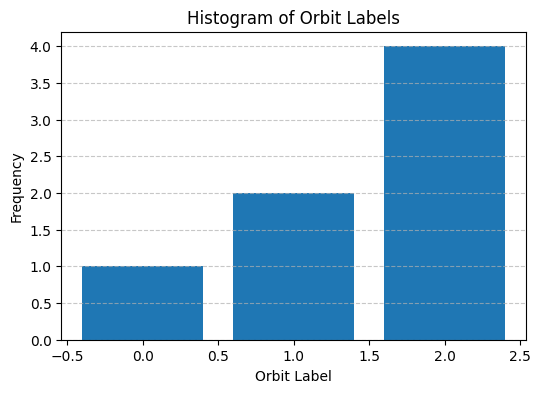

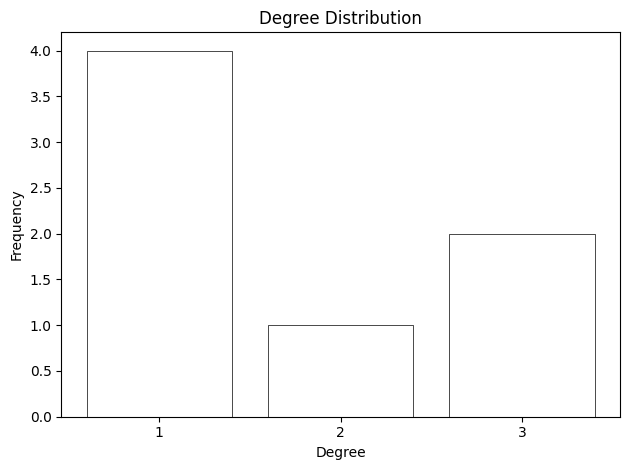

Number of orbits: 4, Tree depth: 3


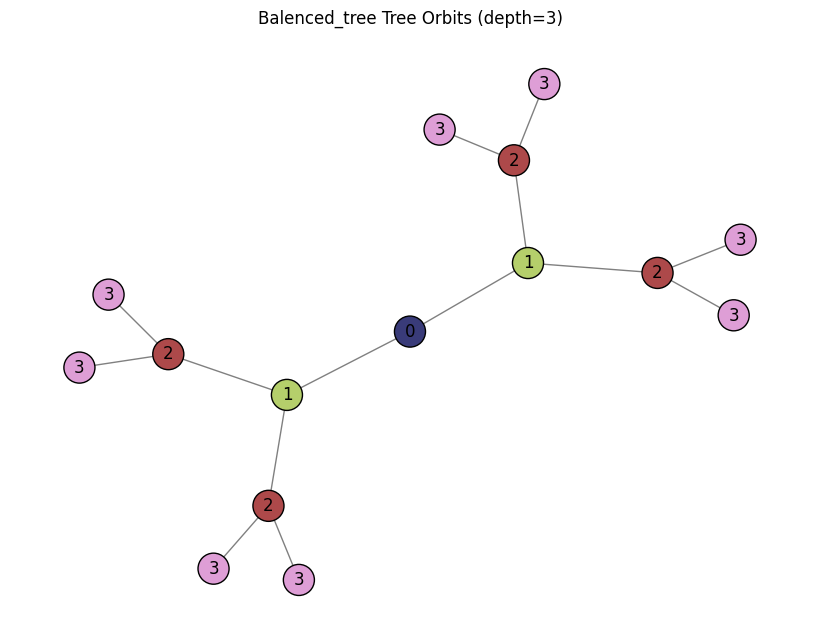

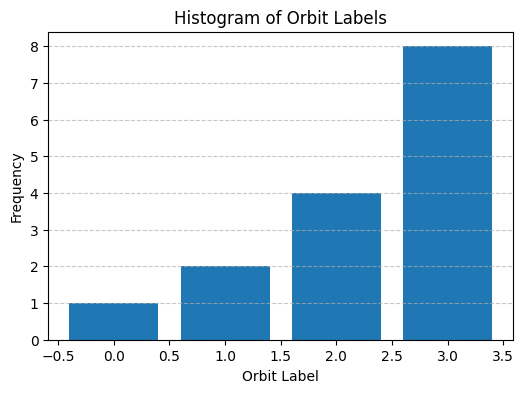

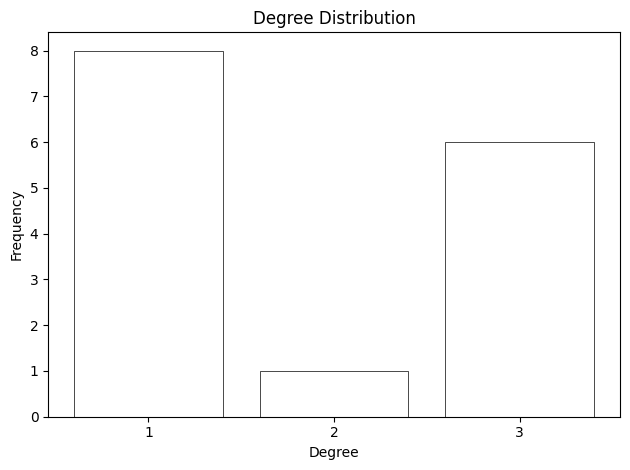

Number of orbits: 5, Tree depth: 4


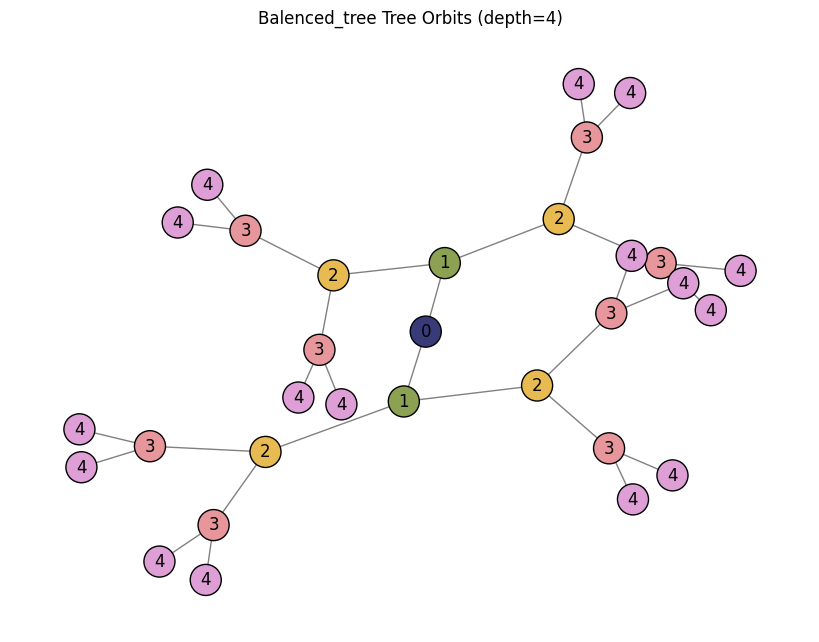

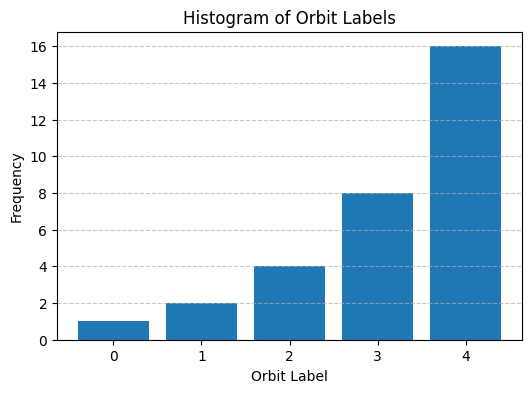

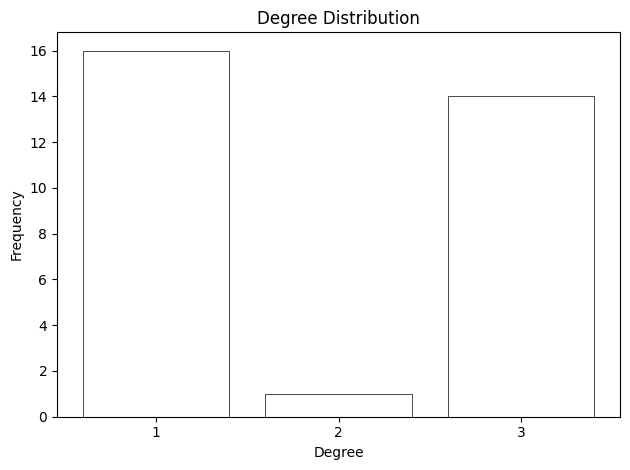

Number of orbits: 6, Tree depth: 5


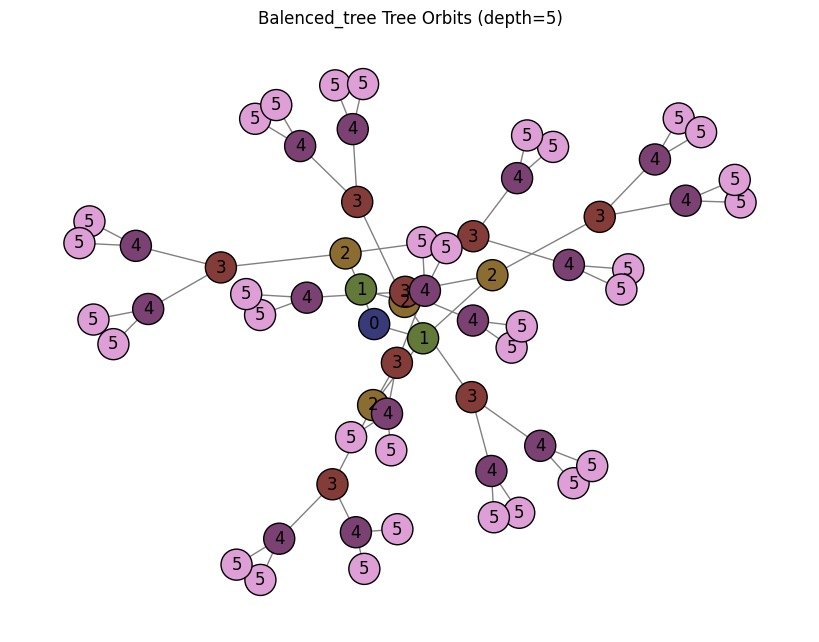

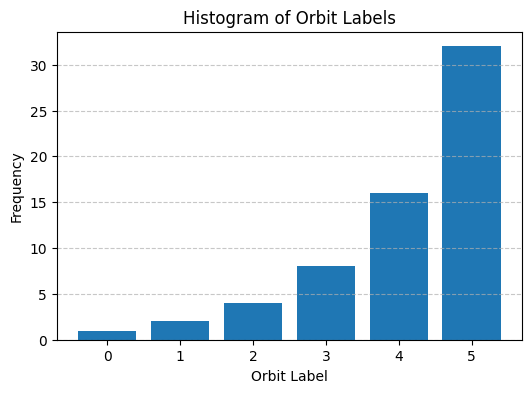

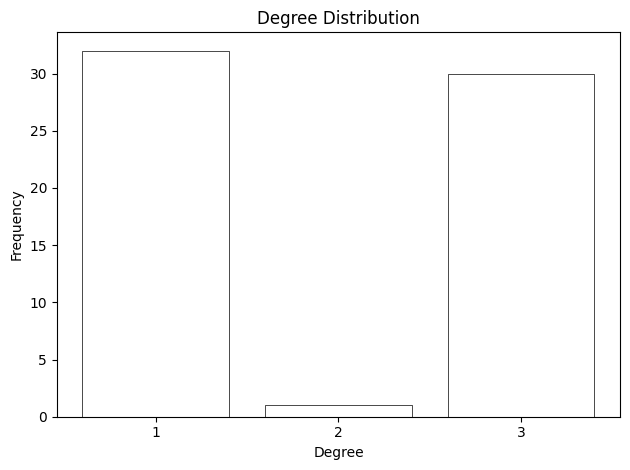

In [4]:
import networkx as nx
import pynauty
import matplotlib.pyplot as plt
import numpy as np
import itertools



for depth in range(2, 6):  
        branch = 2  
        name = 'balenced_tree'
        tree = nx.balanced_tree(r=branch, h=depth)
        pos = nx.spring_layout(tree, seed=42)
        # node_mapping = {node: idx for idx, node in enumerate(tree.nodes())}
        # adj_dict = {
        #         node_mapping[node]: [node_mapping[neighbor] for neighbor in tree.neighbors(node)]
        #         for node in tree.nodes()
        # }

        num_nodes = len(tree.nodes())
        # G_pynauty = pynauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict, directed=False)
        
        # _, _, _, orbits, num_orbit = pynauty.autgrp(G_pynauty)
        orbits, num_orbit = get_graph_orbits(tree)
        new_label_mapping = {node: idx for idx, node in enumerate(set(orbits))}
        orbits = [new_label_mapping[orbit] for orbit in orbits]

        print(f"Number of orbits: {num_orbit}, Tree depth: {depth}")
        node_colors = [orbits[node] for node in range(num_nodes)]

        custom_labels = {}
        for orbit_idx, orbit in enumerate(orbits):
                custom_labels[orbit_idx] = f"{orbits[orbit_idx]}"  # Label all nodes in the orbit with its index

        plt.figure(figsize=(8, 6))
        nx.draw(
        tree,
        pos,
        with_labels=True,
        labels=custom_labels,
        node_color=node_colors,
        cmap='tab20b',
        node_size=500,
        edge_color="gray",
        edgecolors='black'
        )
        plt.title(f"{name.capitalize()} Tree Orbits (depth={depth})")
        plt.show()
        # plt.savefig(f"{name}_tree_orbits_d{depth}.pdf")
        plt.close()
        

        plt.figure(figsize=(6, 4))
        plt.hist(orbits, bins=range(min(orbits), max(orbits) + 2), align='left', rwidth=0.8)
        plt.xlabel('Orbit Label')
        plt.ylabel('Frequency')
        plt.title('Histogram of Orbit Labels')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        # plt.savefig(f"{name}_distribution_d{depth}.pdf")
        plt.close()

        plot_degree_distribution(tree)

In [5]:
num_orbit

6

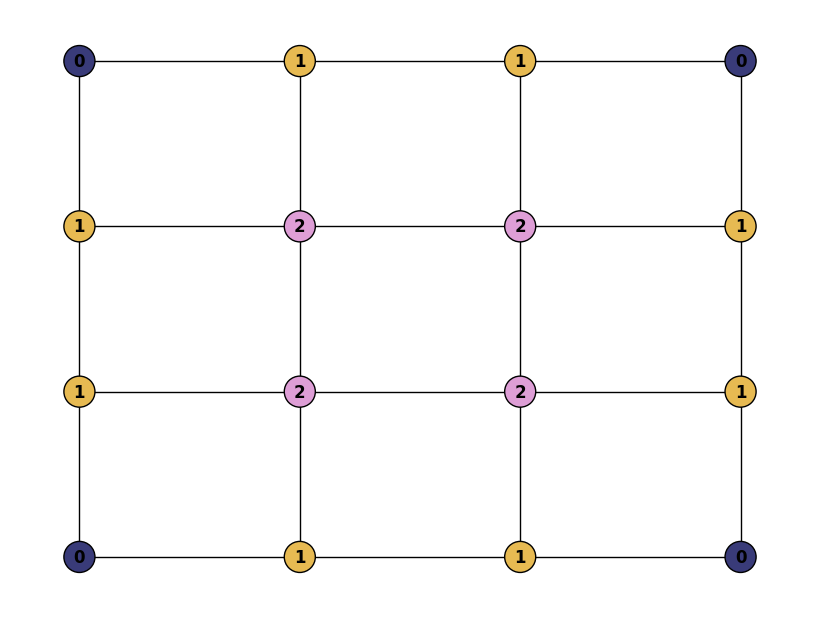

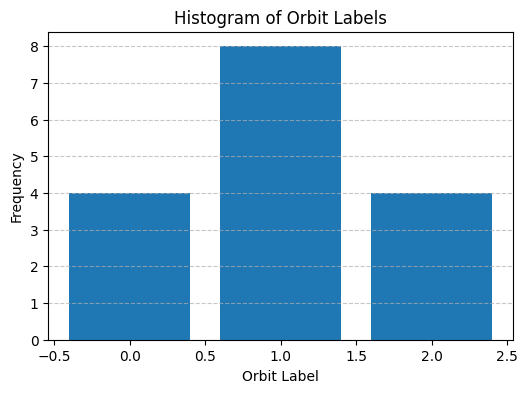

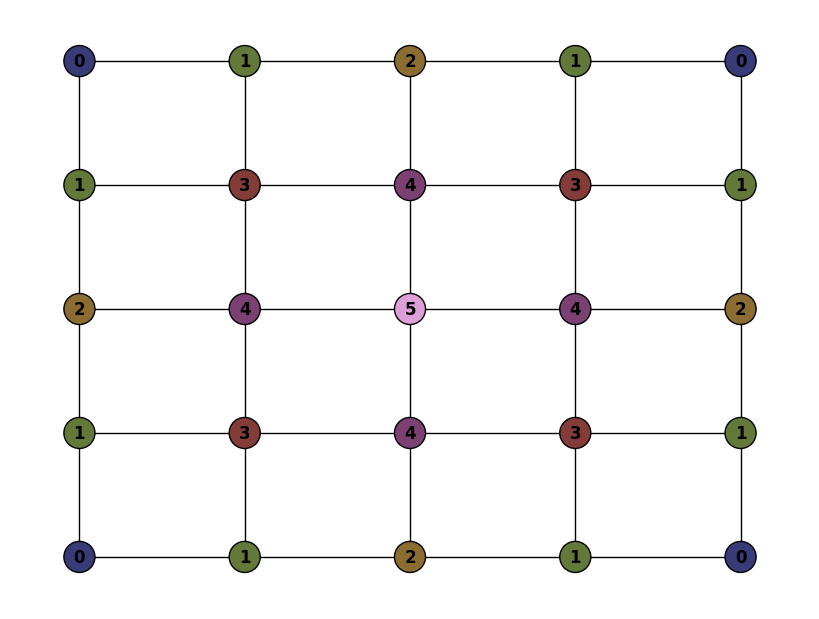

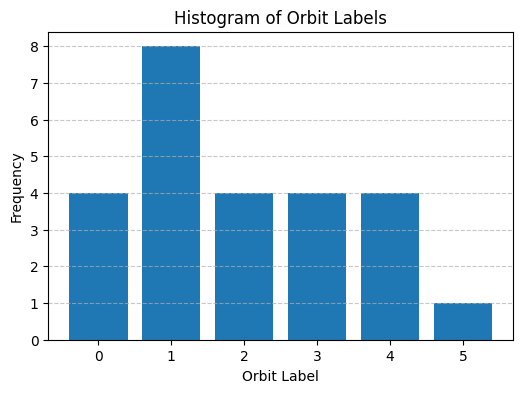

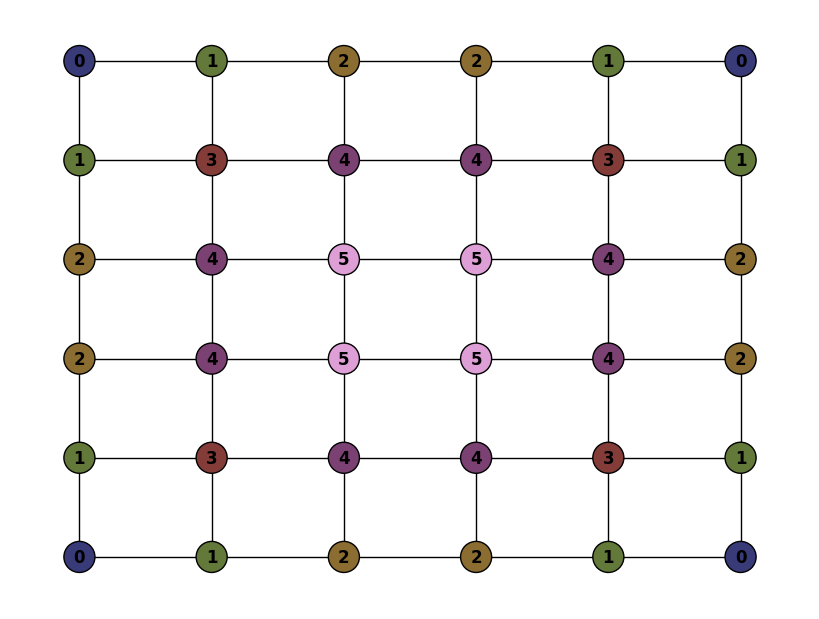

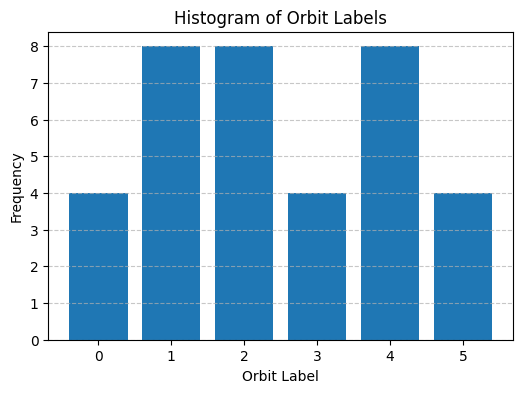

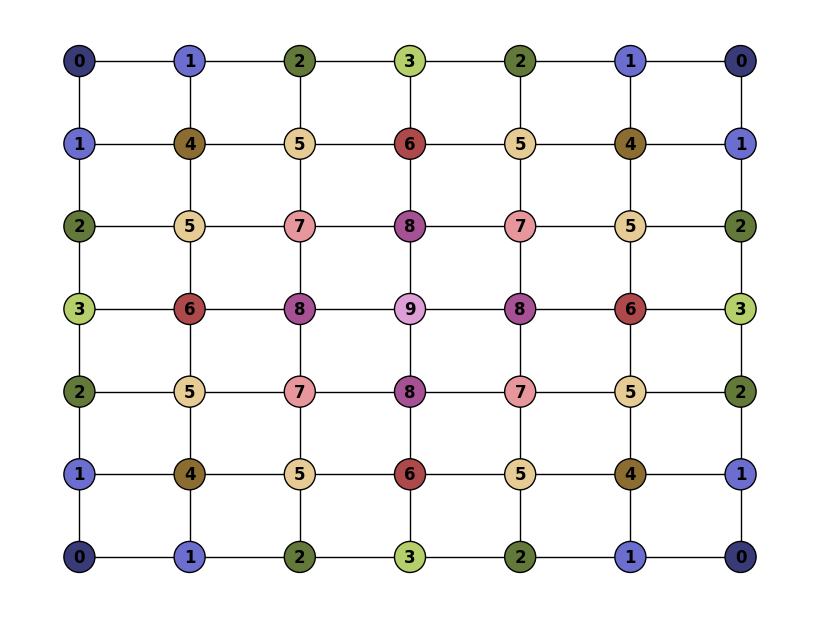

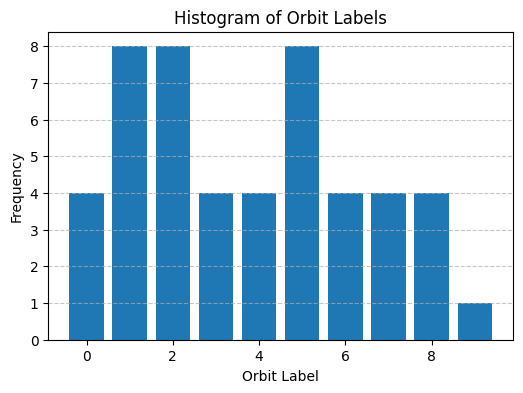

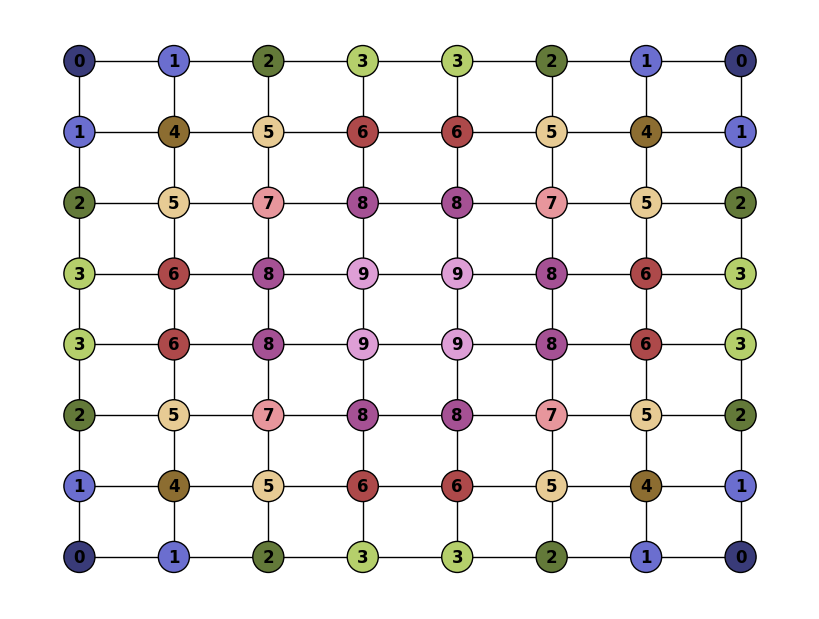

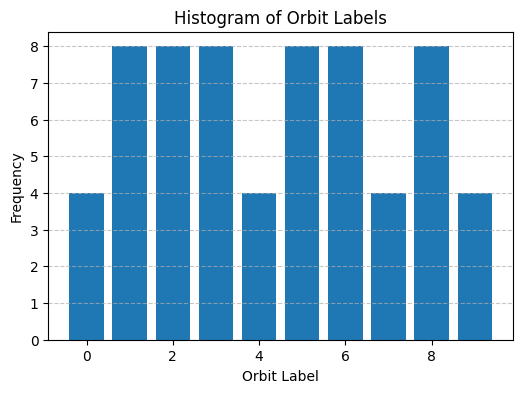

In [6]:
for N in range(4, 9):
        name = 'grid'
        G_nx = nx.grid_2d_graph(N, N)
        pos_original = {node: (node[1], -node[0]) for node in G_nx.nodes()}  
        node_mapping = {node: idx for idx, node in enumerate(G_nx.nodes())}
        adj_dict = {node_mapping[node]: [node_mapping[neighbor] for neighbor in G_nx.neighbors(node)] 
                for node in G_nx.nodes()}
        n = len(G_nx.nodes())
        G_pynauty = pynauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict, directed=False)
        

        # return -> (generators, grpsize1, grpsize2, orbits, numorbits)
        #     For the detailed description of the returned components, see
        generators, _, _,  orbits, num_orbit  = pynauty.autgrp(G_pynauty)
        new_label_mapping = {node: idx for idx, node in enumerate(set(orbits))}
        orbits = [new_label_mapping[orbit] for orbit in orbits]
        custom_labels = {}
        for i, ov in zip(G_nx.nodes(), orbits):
                custom_labels[i] = f"{ov}"


        # nx.draw(G_nx,  
        #         pos=pos_original, 
        #         # with_labels=True, 
        #         labels=custom_labels, 
        #         node_color=node_colors, 
        #         cmap='Blues',
        #         node_size=500, 
        #         font_weight='bold',
        #         edgecolors='black')
        # plt.savefig(f"orbits{N}_{name}new.pdf")
        # plt.show()
        # plt.close()
        plt.figure(figsize=(8, 6))
        node_colors = [orbits[node] for node in range(n)]  
        nx.draw(G_nx,  
                pos=pos_original, 
                # with_labels=True, 
                labels=custom_labels, 
                node_color=node_colors, 
                cmap='tab20b',
                node_size=500, 
                font_weight='bold',
                edgecolors='black')
        # plt.savefig(f"orbits{N}_{name}new.pdf")
        plt.show()
        plt.close()
        
        plt.figure(figsize=(6, 4))
        plt.hist(orbits, 
                 bins=range(min(orbits), max(orbits) + 2), 
                 align='left', 
                 rwidth=0.8)
        plt.xlabel('Orbit Label')
        plt.ylabel('Frequency')
        plt.title('Histogram of Orbit Labels')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        # plt.savefig(f"{name}_distribution_d{depth}_new.pdf")
        plt.close()

        

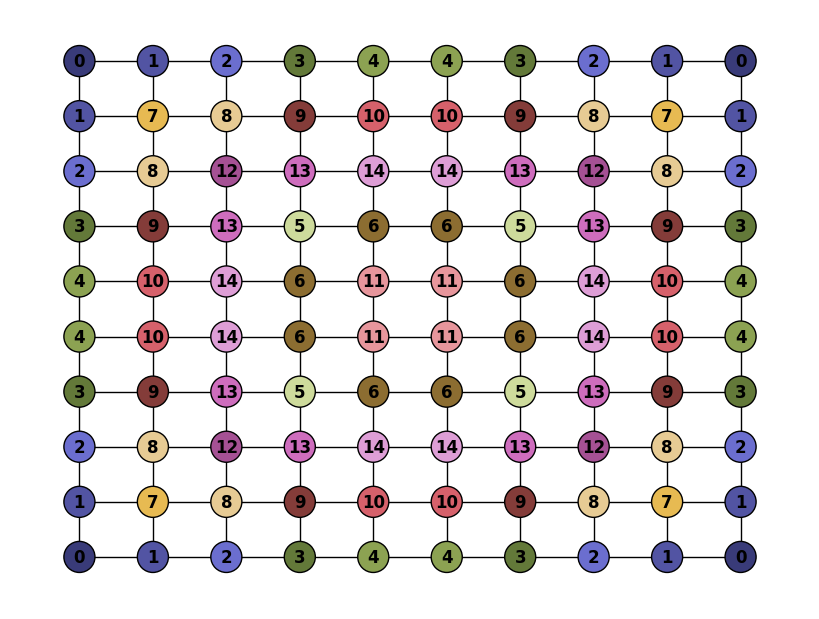

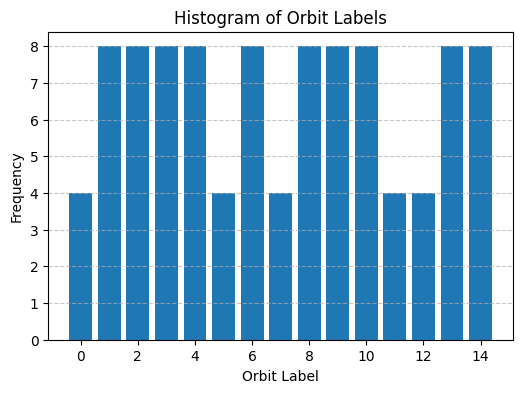

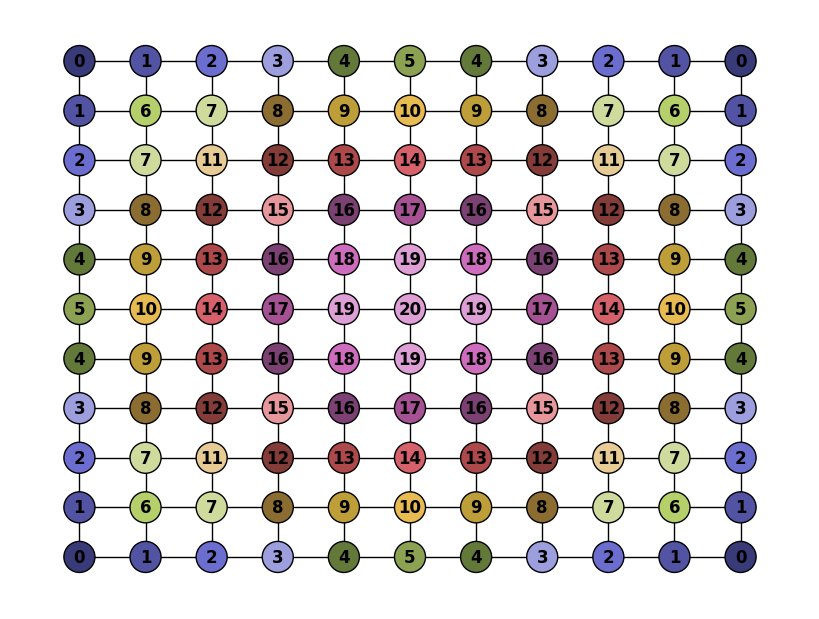

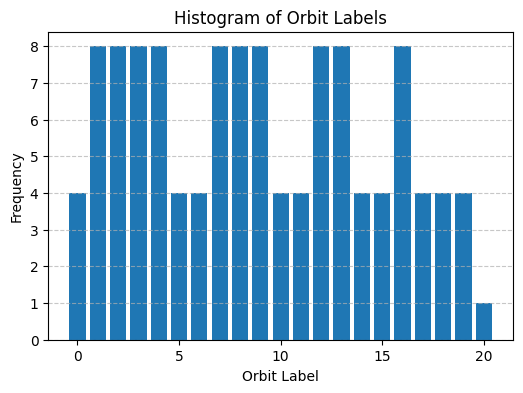

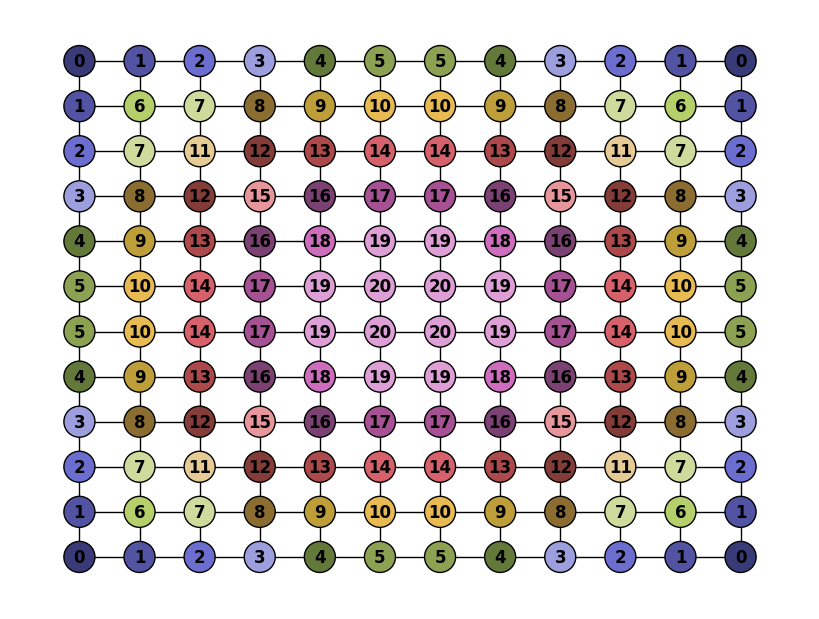

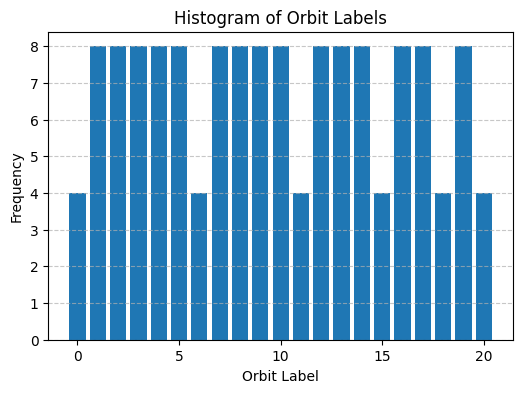

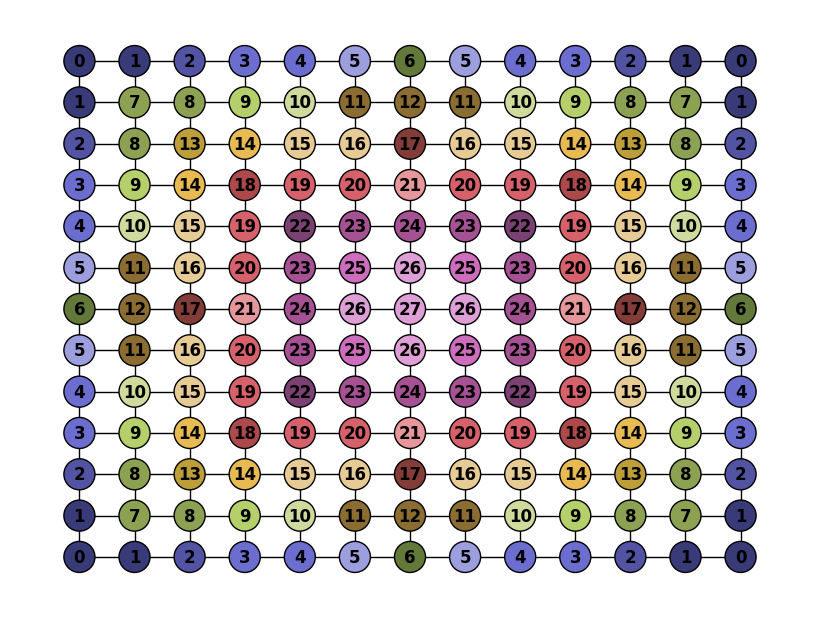

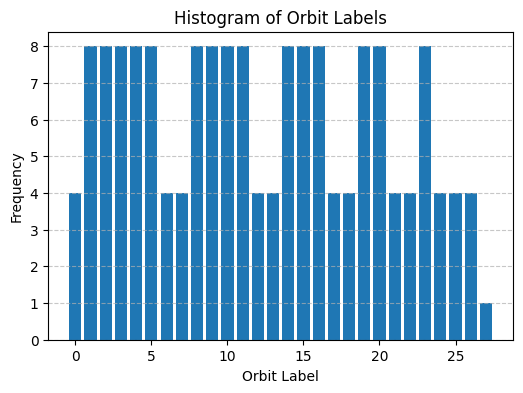

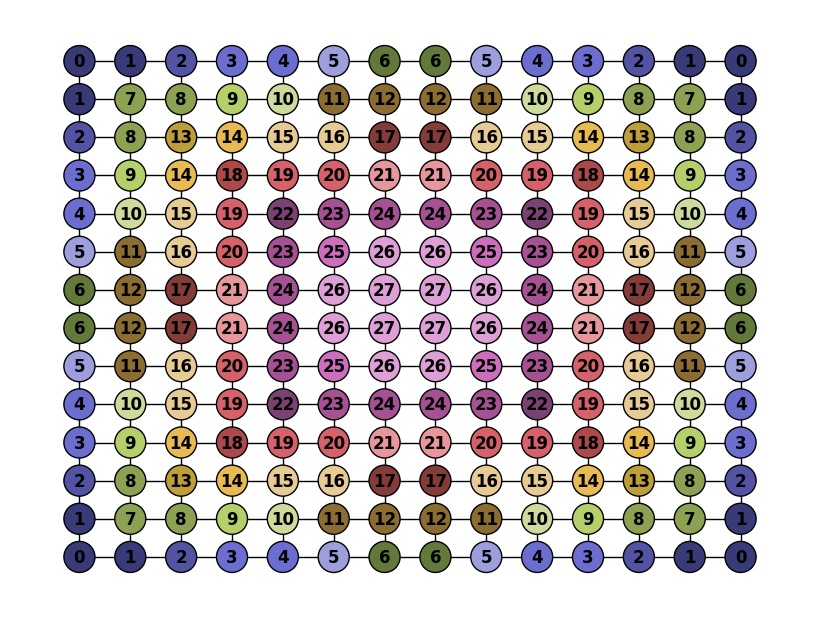

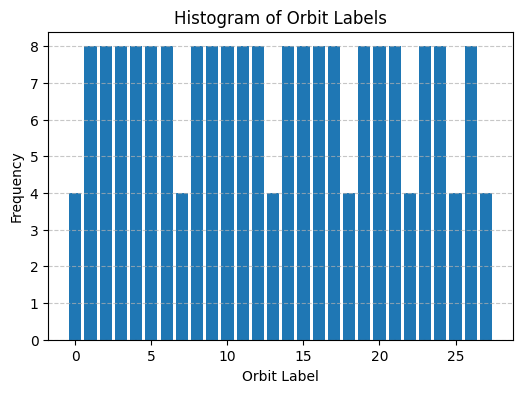

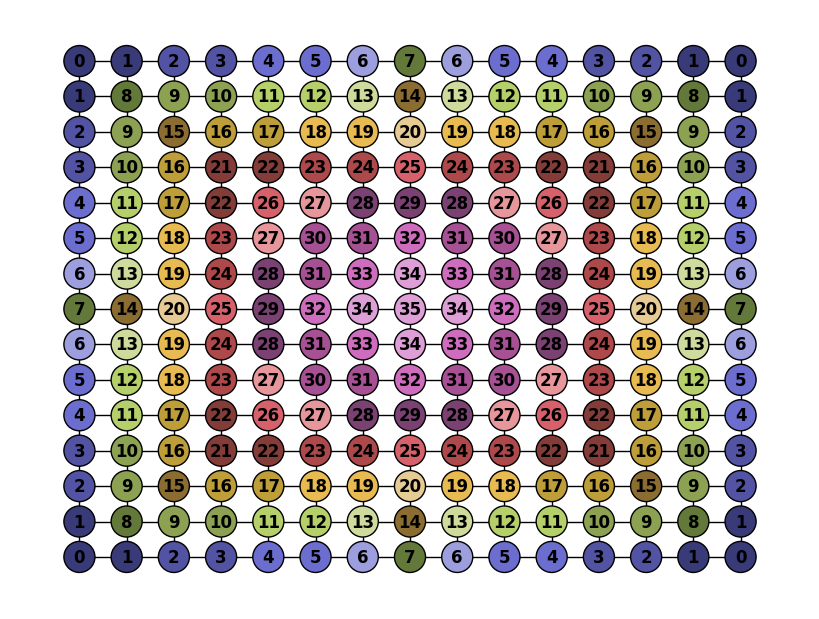

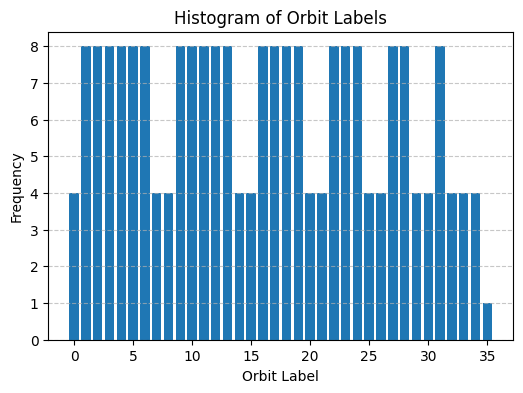

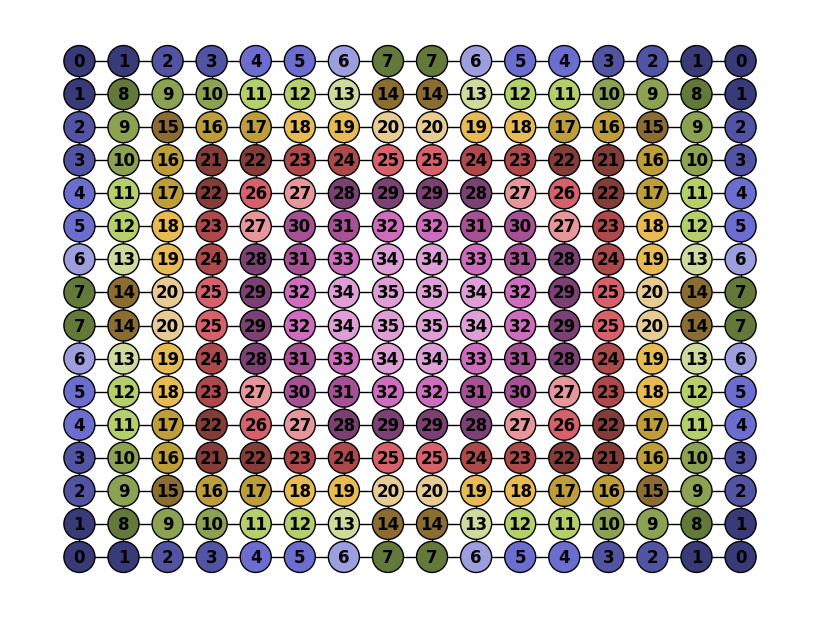

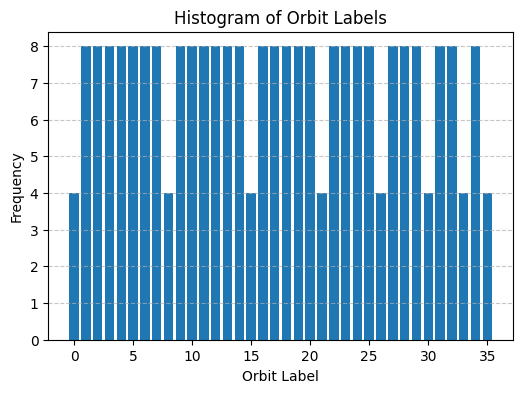

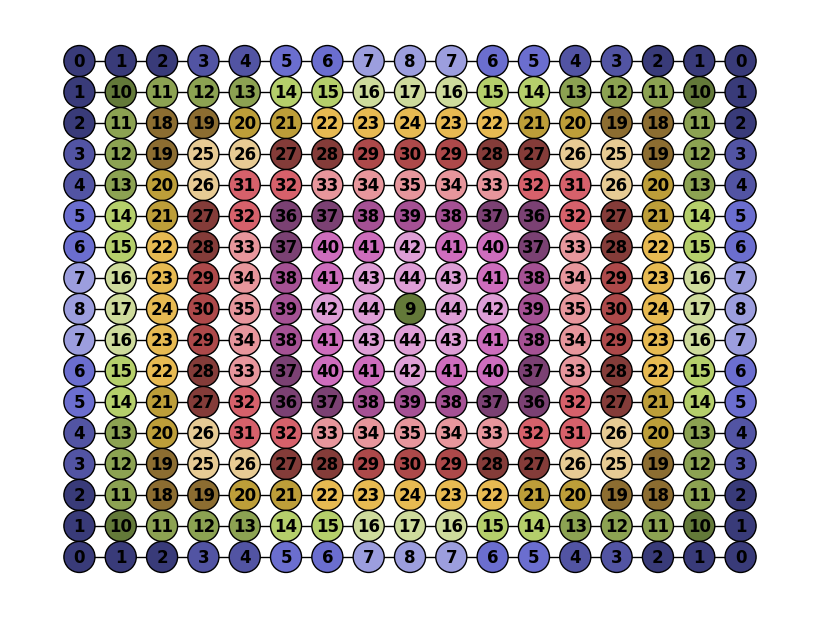

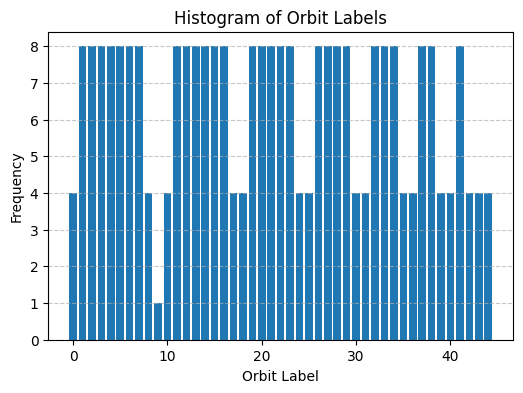

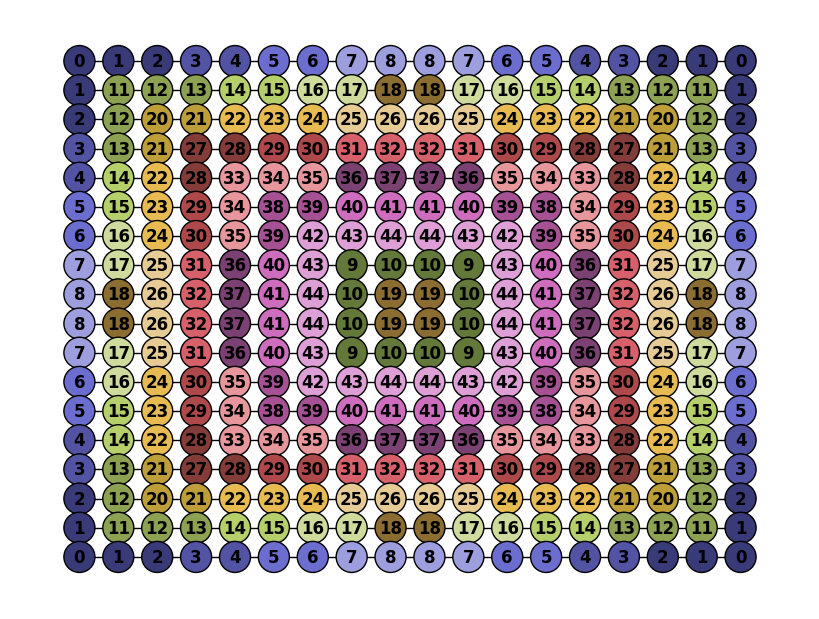

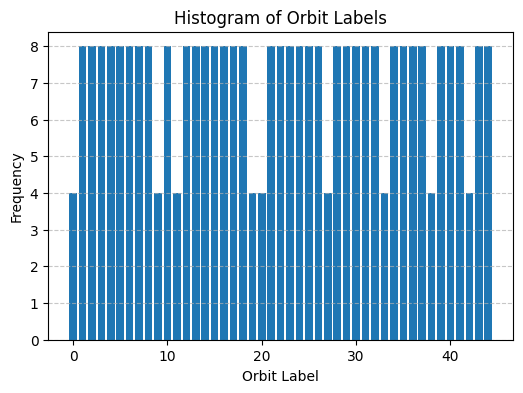

In [7]:
for N in range(10, 19):
        name = 'grid'
        G_nx = nx.grid_2d_graph(N, N)
        pos_original = {node: (node[1], -node[0]) for node in G_nx.nodes()}  
        node_mapping = {node: idx for idx, node in enumerate(G_nx.nodes())}
        adj_dict = {node_mapping[node]: [node_mapping[neighbor] for neighbor in G_nx.neighbors(node)] 
                for node in G_nx.nodes()}
        n = len(G_nx.nodes())
        G_pynauty = pynauty.Graph(number_of_vertices=n, adjacency_dict=adj_dict, directed=False)
        

        # return -> (generators, grpsize1, grpsize2, orbits, numorbits)
        #     For the detailed description of the returned components, see
        _, _, _,  orbits, num_orbit  = pynauty.autgrp(G_pynauty)
        new_label_mapping = {node: idx for idx, node in enumerate(set(orbits))}
        orbits = [new_label_mapping[orbit] for orbit in orbits]
        custom_labels = {}
        for i, ov in zip(G_nx.nodes(), orbits):
                custom_labels[i] = f"{ov}"


        # nx.draw(G_nx,  
        #         pos=pos_original, 
        #         # with_labels=True, 
        #         labels=custom_labels, 
        #         node_color=node_colors, 
        #         cmap='Blues',
        #         node_size=500, 
        #         font_weight='bold',
        #         edgecolors='black')
        # plt.savefig(f"orbits{N}_{name}new.pdf")
        # plt.show()
        # plt.close()
        plt.figure(figsize=(8, 6))
        node_colors = [orbits[node] for node in range(n)]  
        nx.draw(G_nx,  
                pos=pos_original, 
                # with_labels=True, 
                labels=custom_labels, 
                node_color=node_colors, 
                cmap='tab20b',
                node_size=500, 
                font_weight='bold',
                edgecolors='black')
        # plt.savefig(f"orbits{N}_{name}new.pdf")
        plt.show()
        plt.close()
        
        plt.figure(figsize=(6, 4))
        plt.hist(orbits, 
                 bins=range(min(orbits), max(orbits) + 2), 
                 align='left', 
                 rwidth=0.8)
        plt.xlabel('Orbit Label')
        plt.ylabel('Frequency')
        plt.title('Histogram of Orbit Labels')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        # plt.savefig(f"{name}_distribution_d{depth}_new.pdf")
        plt.close()

